<a href="https://colab.research.google.com/github/Nikhilkumar77817/Data-Science/blob/main/MachineLearning__2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
insurance_data= pd.read_csv("/content/16.insurance.csv")

In [ ]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
X= insurance_data.drop(columns=["charges"])
y= insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True,dtype=int )

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)



In [ ]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# MSE low → model achha
# MSE high → model kharab

Mean Squared Error: 20921803.698431376


In [ ]:
# Ye list batati hai ki hum Lasso model ko kitni penalty dena chahte hain
# Small alpha → kam penalty (model flexible)
# Large alpha → zyada penalty (model simple)

alphas = [0.1,1,2,3,6,10,20,30,50,80,100]
mses = []

for a in alphas:
  lasso_model = Lasso(alpha=a)
  lasso_model.fit(X_train, y_train)
  y_pred = lasso_model.predict(X_test)
  MSE = mean_squared_error(y_test, y_pred)
  print(f"MSE for alpha={a}:" ,MSE)
  mses.append(MSE)

# MSE low → model good
# MSE high → model bad

MSE for alpha=0.1: 20921803.698431376
MSE for alpha=1: 20914832.63508914
MSE for alpha=2: 20908106.779954515
MSE for alpha=3: 20901927.931570224
MSE for alpha=6: 20886178.838931825
MSE for alpha=10: 20872844.794796683
MSE for alpha=20: 20877828.53237883
MSE for alpha=30: 20937537.133939773
MSE for alpha=50: 21196929.8696089
MSE for alpha=80: 21860927.299760208
MSE for alpha=100: 22423172.686023254


<Axes: >

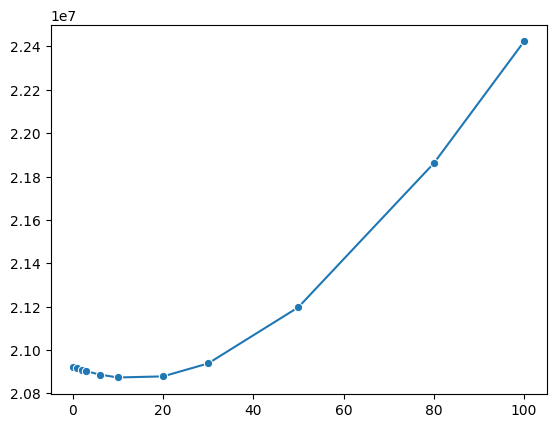

In [ ]:
sns.lineplot(x=alphas, y=mses , marker="o")

In [ ]:
# cross validation
from sklearn.linear_model import LassoCV  # lasso + CV \\ LassoCV = Smart Lasso jo khud best alpha choose karta hai using cross-validation
a = [0.1,1,2,3,6,10,20,30,50,80,100]
lasso_cv_model = LassoCV(alphas=a, cv=5, max_iter=1000,random_state=42)
lasso_cv_model.fit(X_train, y_train)
print("best alpha : ",lasso_cv_model.alpha_)
y_pred=lasso_cv_model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)
print("MSE : ",MSE)

r2 = lasso_cv_model.score(X_test, y_test)
print("R2 : ",r2)

best alpha :  0.1
MSE :  20921803.698431376
R2 :  0.865236878283028


**Why use LassoCV instead of Lasso?**

* Automatic hyperparameter tuning
* Uses cross-validation
* Reduces overfitting
* More robust model

In [ ]:
# cross validation
from sklearn.linear_model import RidgeCV
a = [0.1,1,2,3,6,10,20,30,50,80,100]
ridge_cv_model = RidgeCV(alphas=a, cv=5)
ridge_cv_model.fit(X_train, y_train)
print("best alpha : ",ridge_cv_model.alpha_)
y_pred=ridge_cv_model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)
print("MSE : ",MSE)



best alpha :  0.1
MSE :  20904627.387111183


#Logistic regression

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

In [ ]:
heart_data = pd.read_csv("/content/17.heart.csv")

In [ ]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
heart_data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:



heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
heart_data["target"].nunique()

2

In [ ]:
X = heart_data.drop(columns=["target"]) # this is our output
y = heart_data["target"]

In [ ]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [ ]:
y.head()

,target
0,1
1,1
2,1
3,1
4,1


In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
#how many y test is  y=1
y_test[y_test == 1]

,target
111,1
60,1
9,1
119,1
33,1
5,1
101,1
45,1
118,1
46,1


In [ ]:
y_train[y_train == 1] # 133
# in logistic yes or no should be equally or nearly divided (50-50, 55-45,60-40,etc)
# warna data biased ho sakta hai

,target
132,1
75,1
59,1
93,1
6,1
...,...
121,1
20,1
71,1
106,1


In [ ]:
y_train[y_train == 0] # 109

,target
202,0
196,0
176,0
177,0
258,0
...,...
257,0
214,0
302,0
188,0


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("accuracy :",accuracy_score(y_test, y_pred))


accuracy : 0.8688524590163934


In [ ]:
print("precision :",precision_score(y_test, y_pred))

precision : 0.875


#scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train

array([[-1.35679832,  0.72250438,  0.00809909, ...,  0.95390513,
        -0.68970073, -0.50904773],
       [ 0.38508599,  0.72250438, -0.97189094, ...,  0.95390513,
        -0.68970073,  1.17848036],
       [-0.92132724,  0.72250438,  0.98808912, ..., -0.69498803,
        -0.68970073, -0.50904773],
       ...,
       [ 1.58263146,  0.72250438,  1.96807914, ..., -0.69498803,
         0.32186034, -0.50904773],
       [-0.92132724,  0.72250438, -0.97189094, ...,  0.95390513,
        -0.68970073,  1.17848036],
       [ 0.92942484, -1.38407465,  0.00809909, ...,  0.95390513,
         1.33342142, -0.50904773]])

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [ ]:
print("accuracy :",accuracy_score(y_test, y_pred))
print("precision :",precision_score(y_test, y_pred))

accuracy : 0.8524590163934426
precision : 0.8709677419354839


In [ ]:
#Evaluation metrices
from sklearn.metrics import confusion_matrix , classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[25  4]
 [ 5 27]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8524590163934426
Precision: 0.8709677419354839
Recall: 0.84375
F1 Score: 0.8571428571428571
